# H2 H1 후보군 분포 검정

H1 K-Means 클러스터링 후보 라벨 `is_stagnant_cluster`를 기본 라벨로 두고, 레벨 구간 및 직업 계열 분포의 독립성을 검정한다. 63명 현재성 후보와 35명 고신뢰 현재성 후보는 보조 분석으로 유지한다. 통계 로직과 산출물 생성은 `run_analysis.py`에 모아 노트북과 명령행 실행 결과가 어긋나지 않게 유지한다.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

root = Path.cwd()
h2_dir = root / "h2_distribution" if (root / "h2_distribution").exists() else root
subprocess.run([sys.executable, str(h2_dir / "run_analysis.py")], check=True)
results = json.loads((h2_dir / "results.json").read_text(encoding="utf-8"))

## 기본 검정

사전 정의한 기본 라벨 `is_stagnant_cluster`의 두 교차표를 확인한다. `p`는 카이제곱 근사값이며 Monte Carlo 검정은 주변합을 고정한 보수적 점검이다.

In [2]:
primary = results["labels"][0]
summary = pd.DataFrame([
    {
        "dimension": test["dimension"],
        "chi2": test["chi2"],
        "df": test["dof"],
        "p": test["p_value"],
        "monte_carlo_p": test["monte_carlo_p_value"],
        "holm_adjusted_p": test["holm_adjusted_p_value"],
        "min_expected": test["min_expected_frequency"],
        "cramers_v": test["cramers_v"],
    }
    for test in primary["tests"]
])
display(Markdown(f"sample **{primary['n']:,}**, H1 candidates **{primary['candidate_n']} ({primary['candidate_rate'] * 100:.2f}%)**"))
display(summary.round(4))


sample **1,999**, H1 candidates **471 (23.56%)**

,dimension,chi2,df,p,monte_carlo_p,holm_adjusted_p,min_expected,cramers_v
0,level_band,37.7461,2,0.000,0.000,0.000,156.4502,0.1374
1,class_group,9.5878,4,0.048,0.049,0.048,94.0115,0.0693


## 레벨 구간 핫스팟

표준화 잔차와 나머지 구간 대비 odds ratio로 집중 구간을 해석한다.


,category,n,candidate_n,candidate_rate_pct,candidate_standardized_residual,odds_ratio_vs_rest,odds_ratio_ci95
0,270-279,664,200,30.120,3.482,1.692,"[1.3679715212192347, 2.0935900623158705]"
1,280-285,665,164,24.662,0.584,1.095,"[0.8809256396442394, 1.3612476096398207]"
2,286-290,670,107,15.970,-4.048,0.504,"[0.39662289870897527, 0.6400661216227972]"


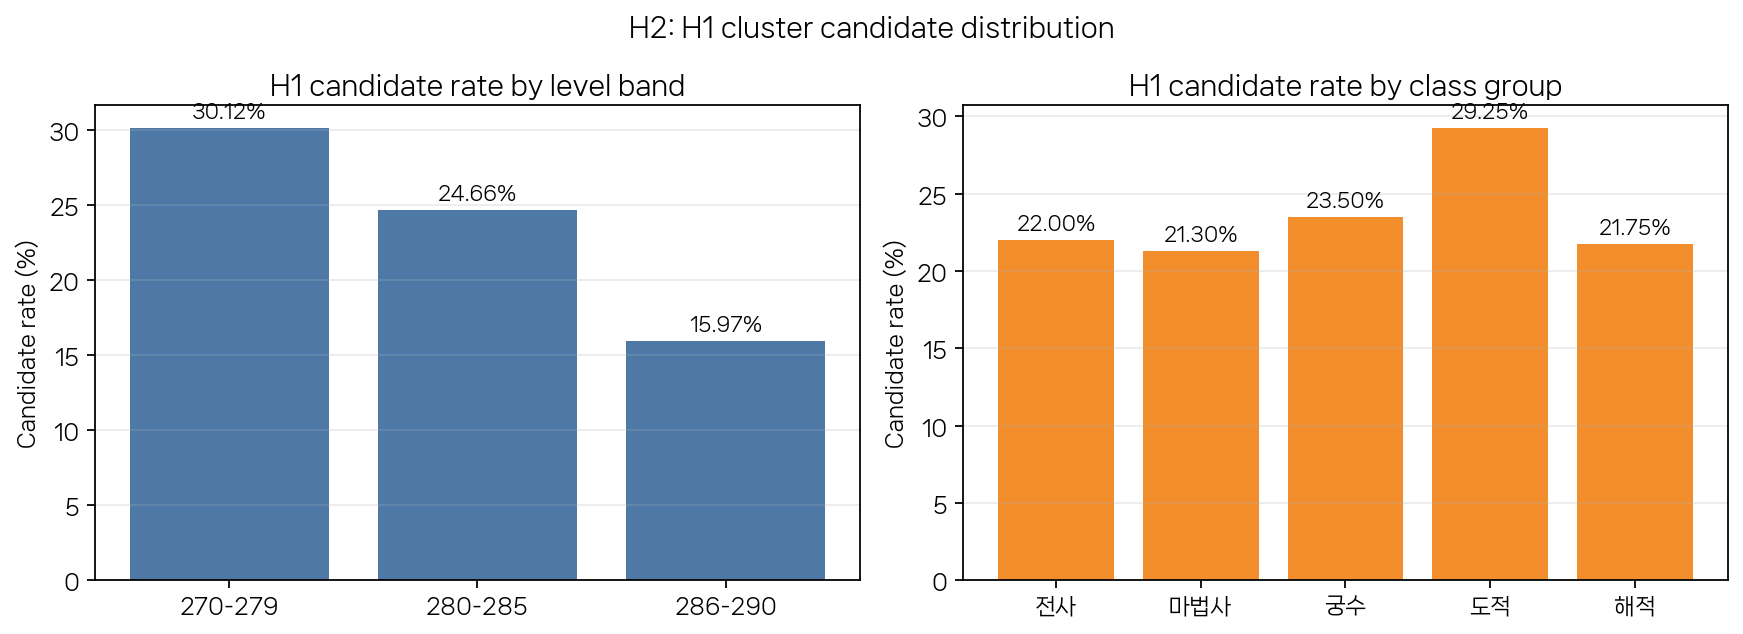

In [3]:
level_rows = pd.DataFrame(primary["tests"][0]["categories"])
level_rows["candidate_rate_pct"] = level_rows["candidate_rate"] * 100
display(level_rows[[
    "category", "n", "candidate_n", "candidate_rate_pct",
    "candidate_standardized_residual", "odds_ratio_vs_rest", "odds_ratio_ci95"
]].round(3))
display(Image(filename=str(h2_dir / "figures" / "candidate_distribution.png")))

## 해석

사전 정의한 기본 레벨 구간 검정은 `p < 0.05`이며 Holm 보정 후에도 유의하다. H1 후보는 `270-279` 구간에서 강하게 집중되고 `286-290` 구간에서는 낮게 관측된다. 직업 계열 집중은 확인되지 않는다. 63명 현재성 후보와 35명 고신뢰 현재성 후보도 같은 방향의 레벨 구간 신호를 보이며, 직업 계열 검정은 유의하지 않다. 상세 수치는 `RESULTS.md`를 참고한다.